In [ ]:
%load_ext autoreload
%autoreload 2

import time
import math
import numpy as np
import torch
import cv2
import json
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

from pathlib import Path
import sys
from typing import Any
import PIL.Image

from project_root import PROJECT_ROOT,DATASETS_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout

from tqdm.auto import tqdm
import torchvision as tv

from scripts.model_serialization import load_model

np.set_printoptions(linewidth=200)
no_grad_guard = torch.no_grad()

2025-04-08 14:57:16.980893: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-08 14:57:16.988259: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744117036.996675 1200477 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744117036.999210 1200477 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744117037.005641 1200477 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# dataset_name =         "zoo-elephants-identity-tracks"
# ds =fo.load_dataset(dataset_name)


def make_ds():
    return fo.Dataset.from_dir(
        dataset_type=fo.types.ImageDirectory,
        dataset_dir="/media/dherrera/ElephantExternal/elephants/tracks/new/identity/03_Fahra/zag_elp_cam_018_000342",
        persistent=False,
    )


ds = make_ds()
# classes = sorted(ds.classes["ground_truth"])
# print(classes)
print(ds)

 100% |█████████████████| 656/656 [48.4ms elapsed, 0s remaining, 13.5K samples/s]  
Name:        2025.04.08.14.57.18
Media type:  image
Num samples: 656
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField


In [4]:
# Compute uniqueness
import fiftyone.brain as fob

session = fo.launch_app(ds, auto=False)
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

In [5]:
import transformers

embeddings_model_path = PROJECT_ROOT / "models/identity/vit/all/config.json"
image_processor = transformers.AutoImageProcessor.from_pretrained(
    embeddings_model_path.parent
)
embeddings_model = load_model(embeddings_model_path)
embeddings_model = embeddings_model.vit.embeddings
embeddings_model

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)

In [6]:
MAX_KEYFRAMES = 40
keyframe_images = [None] * MAX_KEYFRAMES
keyframe_embeddings = [None] * MAX_KEYFRAMES
keyframe_similarities = torch.ones((MAX_KEYFRAMES, MAX_KEYFRAMES))
# keyframe_similarities.fill_diagonal_(0)

sample_iter = ds.iter_samples()

In [15]:
sample = next(ds.iter_samples())
image = PIL.Image.open(sample["filepath"])
pixel_values = image_processor.preprocess(image)["pixel_values"]
pixel_values = np.stack(pixel_values, 0)
pixel_values = torch.from_numpy(pixel_values)
embeddings = embeddings_model.forward(pixel_values)

print([*embeddings.shape])
print(math.prod([*embeddings.shape]) / 1024)

[1, 197, 768]
147.75


In [6]:
def replace_similarity_matrix_entry(m, idx, v):
    vidx = min(len(v), idx)
    m[idx, idx] = 0
    m[0:idx, idx] = v[0:vidx]
    m[idx, 0:idx] = v[0:vidx]
    if idx < len(m) - 1:
        m[idx + 1 :, idx] = v[vidx + 1 :]
        m[idx, idx + 1 :] = v[vidx + 1 :]


for si, sample_i in tqdm(enumerate(ds.iter_samples())):
    try:
        image_path = sample_i["filepath"]
        image = PIL.Image.open(image_path)
        image = np.asarray(image)
        pixel_values = image_processor.preprocess(image)["pixel_values"]
        pixel_values = np.stack(pixel_values, 0)
        pixel_values = torch.from_numpy(pixel_values)
        embeddings_i = embeddings_model.forward(pixel_values)
        embeddings_i_norm = torch.linalg.norm(embeddings_i.reshape(-1))

        # Get the similarity between new image and keyframes
        similarities_i = torch.tensor(
            [
                (
                    (
                        torch.dot(embeddings_i.reshape(-1), kf.reshape(-1))
                        / (torch.linalg.norm(kf) * embeddings_i_norm)
                    )
                    if kf is not None
                    else 0
                )
                for kf in keyframe_embeddings
            ]
        )
        max_similarity_i, max_similarity_i_idx = (
            torch.max(similarities_i, dim=0) if len(similarities_i) > 0 else (0, 0)
        )
        MAX_SIMILARITY_THRESHOLD = 0.8
        if max_similarity_i > MAX_SIMILARITY_THRESHOLD:
            msg = f"Skipping frame due to high similarity: {max_similarity_i}"
        else:
            # Get the highest similarity between keyframes
            keyframe_highest_similarities, keyframe_highest_similarities_idx = (
                torch.max(keyframe_similarities, dim=0)
            )  # [keyframe], [keyframe]
            highest_similarity, highest_similarity_idx = torch.max(
                keyframe_highest_similarities, dim=0
            )  # scalar, scalar
            most_similar_frame_idxs = [
                highest_similarity_idx.item(),
                keyframe_highest_similarities_idx[highest_similarity_idx].item(),
            ]

            if max_similarity_i < highest_similarity:
                # Replace a keyframe
                most_similar_frame_l2 = torch.linalg.norm(
                    keyframe_similarities[most_similar_frame_idxs]
                )
                _, idx = torch.max(most_similar_frame_l2, dim=0)
                keyframe_to_replace_idx = most_similar_frame_idxs[idx]
                msg = f"Replacing keyframe #{keyframe_to_replace_idx}"

                keyframe_images[keyframe_to_replace_idx] = image
                keyframe_embeddings[keyframe_to_replace_idx] = embeddings_i
                replace_similarity_matrix_entry(
                    keyframe_similarities, keyframe_to_replace_idx, similarities_i
                )
            else:
                msg = f"Ignoring image because it has higher similarity ({max_similarity_i}, idx={max_similarity_i_idx}) than the most similar keyframe ({highest_similarity}, idx=({most_similar_frame_idxs}))"
        print(msg)
    except KeyboardInterrupt:
        break

0it [00:00, ?it/s]

Replacing keyframe #0
Skipping frame due to high similarity: 0.8509859442710876
Replacing keyframe #1
Replacing keyframe #2
Replacing keyframe #3
Replacing keyframe #4
Replacing keyframe #5
Replacing keyframe #6
Replacing keyframe #7
Replacing keyframe #8
Replacing keyframe #9
Replacing keyframe #10
Skipping frame due to high similarity: 0.8040539622306824
Skipping frame due to high similarity: 0.8790649175643921
Replacing keyframe #11
Skipping frame due to high similarity: 0.8079386353492737
Replacing keyframe #12
Replacing keyframe #13
Replacing keyframe #14
Replacing keyframe #15
Replacing keyframe #16
Replacing keyframe #17
Skipping frame due to high similarity: 0.8083608150482178
Replacing keyframe #18
Replacing keyframe #19
Replacing keyframe #20
Skipping frame due to high similarity: 0.8212941884994507
Skipping frame due to high similarity: 0.8946918845176697
Skipping frame due to high similarity: 0.9570162892341614
Skipping frame due to high similarity: 0.8977814316749573
Skipp

[[0.         0.7037313  0.2915889  ... 0.21010043 0.33673495 0.38017547]
 [0.7037313  0.         0.2843751  ... 0.15737744 0.27477574 0.31416625]
 [0.2915889  0.2843751  0.         ... 0.17074017 0.19410333 0.24945952]
 ...
 [0.21010043 0.15737744 0.17074017 ... 0.         0.21493831 0.26513946]
 [0.33673495 0.27477574 0.19410333 ... 0.21493831 0.         0.5474353 ]
 [0.38017547 0.31416625 0.24945952 ... 0.26513946 0.5474353  0.        ]]


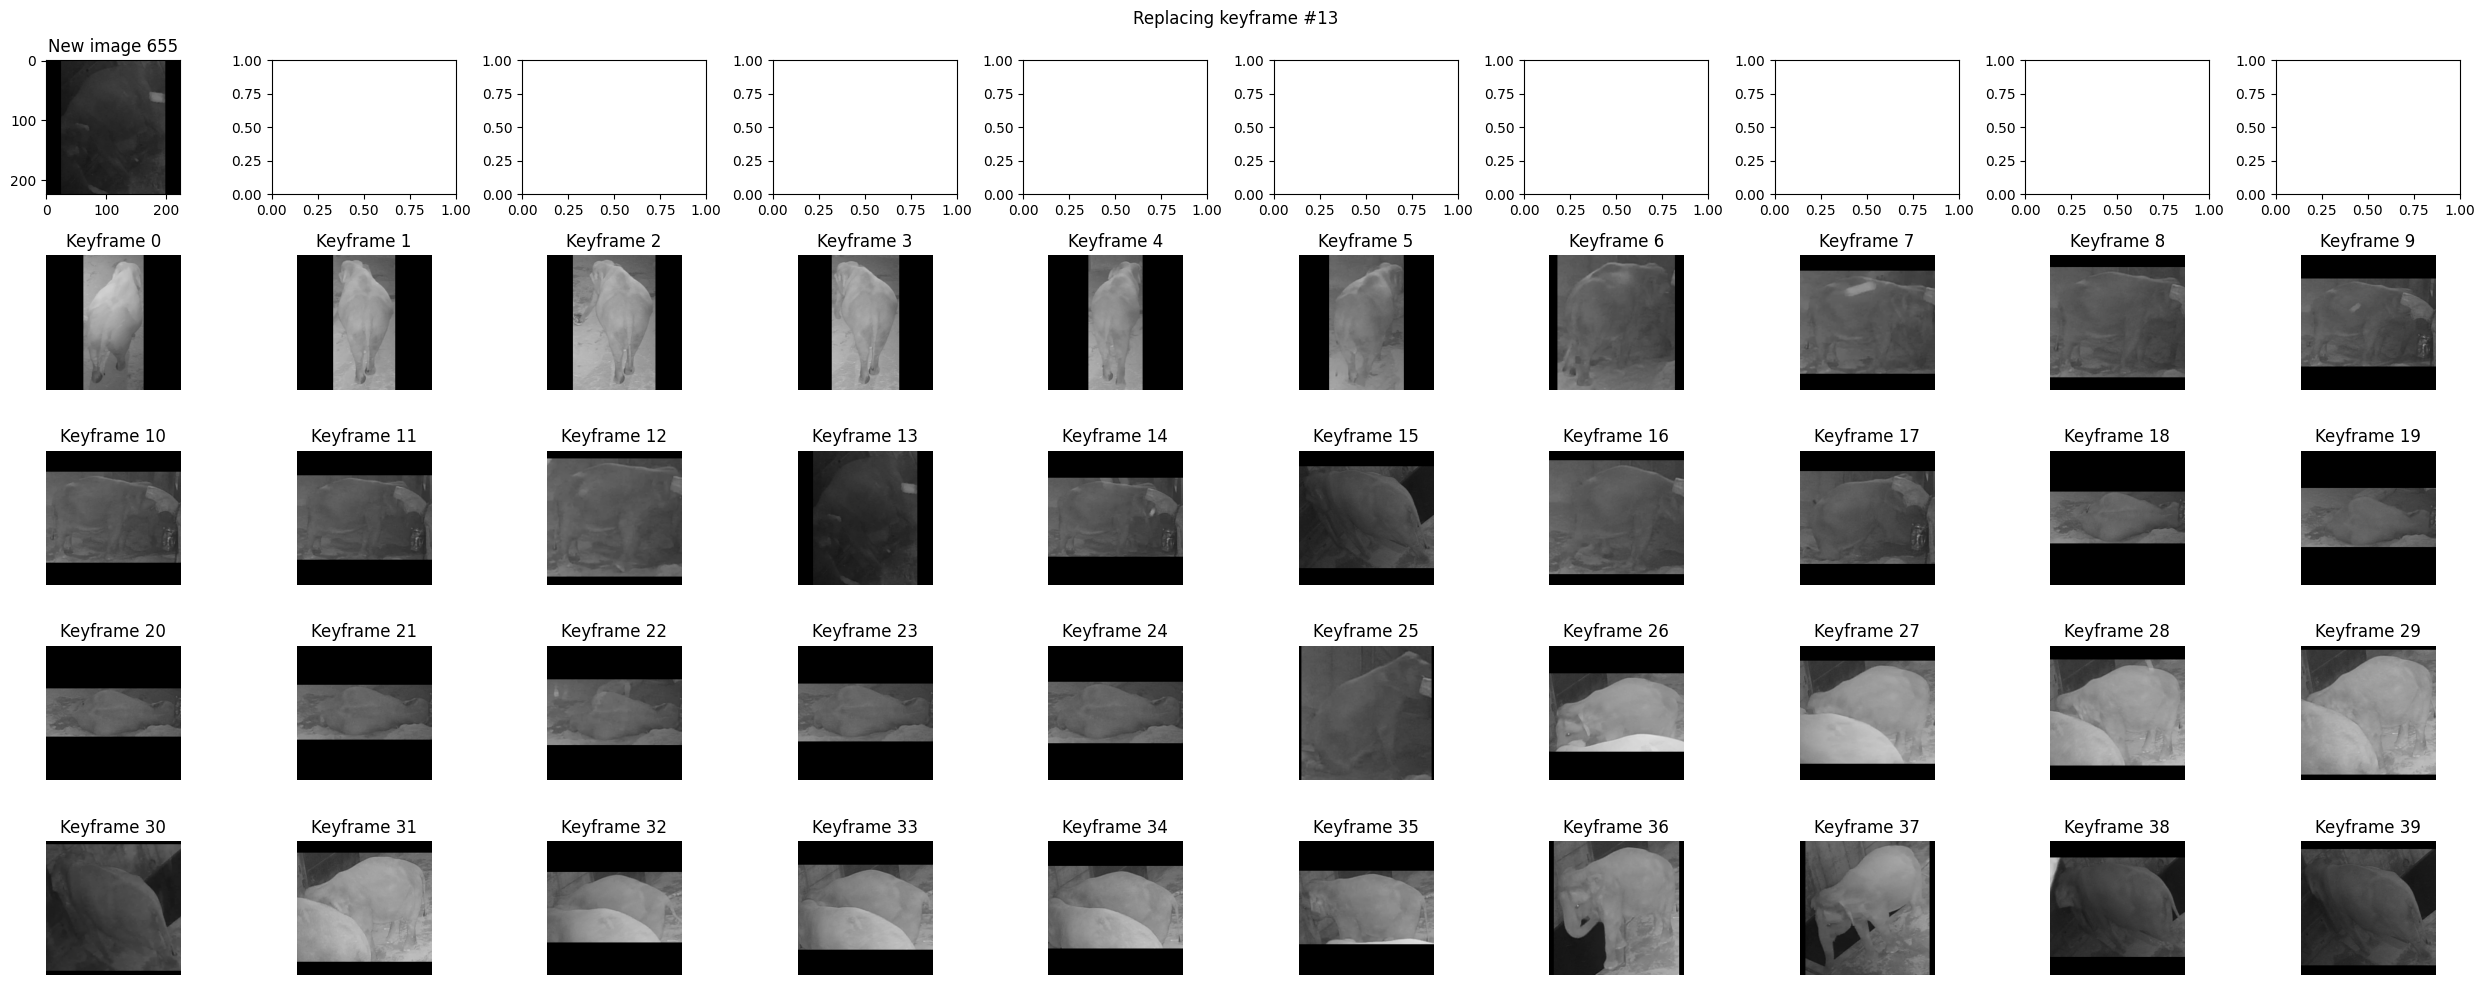

In [7]:
print(keyframe_similarities.numpy())
nrows = 5
ncols = 10
fig, axs = plt.subplots(nrows, ncols, figsize=(25, 10))
ax: Axes = axs[0, 0]
ax.imshow(image)
ax.set_title(f"New image {si}")
axs = axs[1:, :].reshape(-1)
for i, im in enumerate(keyframe_images):
    if im is None:
        continue
    ax = axs[i]
    ax.imshow(im)
    ax.set_axis_off()
    ax.set_title(f"Keyframe {i}")
fig.suptitle(msg)
fig.tight_layout()
# display.display(plt.gcf())
# display.clear_output(wait=True)
# time.sleep(0.1)
plt.show()